# 变系数模型

本讲由浅入深地介绍三个模型，帮助大家理解变系数模型的基本思想及其与交互项模型、面板门槛模型的关系。

- 通过引入交互项实现变系数模型
- 函数系数模型 (基于非参数样条回归)
- 面板门槛模型 

你会发现，引入交互项是最直接、最容易解释的变系数模型设定方法；而函数系数模型则有非常扎实的统计性质。相比之下，面板门槛模型基本上可以看作是变系数模型的一个特例 (即系数在某个门槛点发生不连续变化)，实证分析中基本上可以放弃了。 

## 简介

考虑如下面板数据模型：

$$Y_{it} = \alpha_i + \gamma_{\color{red}{i}\color{blue}{t}} Z_{it} + X_{it}\beta + \mu_{it} \qquad \frac{\partial Y}{\partial Z} = \gamma_{it} \tag{1}$$

其中，$i$表示个体，$t$表示时间。基于理论分析，我们预期，$Z$ 对 $Y$ 的边际影响具有异质性，即 ${\partial Y}/{\partial Z}$ 会随着时间 $t$ 和 (或) $i$ 的变化而变化，表示为 $\gamma_{it}$。

显然，如果不做任何限制，$\gamma_{it}$ 可以是任意形式的异质性，模型无法识别。一个基本思路是降维，我们可以假设 $\gamma_{it}$ 仅与某个变量 $U_{it}$ 有关，二者之间的函数关系为 $\gamma(U_{it})$。例如，我们可以假设 $\gamma(U_{it})$ 是 $U_{it}$ 的线性函数，即 $\gamma(U_{it}) = \theta_0 + \theta_1 U_{it}$。这里隐含的假设是，$Z$ 对 $Y$ 的边际影响随着 $U$ 的变化而线性变化。其中，

- $\theta_0 = {\partial Y}/{\partial Z} \big|_{U=0}$，表示当 $U=0$ 时，$Z$ 对 $Y$ 的边际影响；

- $\theta_1 = \frac{\partial({\partial Y}/{\partial Z})}{\partial {U}}$，表示 $U$ 每增加一个单位，$Z$ 对 $Y$ 的边际影响的变化量，即 $Z$ 对 $Y$ 的边际影响如何随着 $U$ 变化而变化。

同理，我们也可以假设 $\gamma(U_{it})$ 是 $U_{it}$ 的二次函数或三次函数等。至于选择什么样的函数形式，可以根据理论预期和数据特征来决定。 

为不失一般性，这里以三次函数为例 (为了便于书写这里省去了下标)，来说明这类变系数模型其实可以转化为一个包含交互项的线性回归模型。

$$
Y = {\color{red}{\gamma(U)}} Z + X\beta + \mu \tag{2a}
$$

$$
{\color{red}{\gamma(U)}} = \theta_0 + \theta_1 U + \theta_2 U^2 + \theta_3 U^3  \tag{2b}
$$

- 代入，可得：$Y = Z(\theta_0 + \theta_1 U + \theta_2 U^2 + \theta_3 U^3) + X\beta + \mu$

- 展开，可得：$Y = \theta_0 Z + \theta_1 (Z\times U) + \theta_2 (Z\times U^2) + \theta_3 (Z\times U^3) + X\beta + \mu$

如此以来，我们就将变系数模型转化为了一个包含交互项的普通线性回归模型。

- 你可以使用 `xtreg` 或 `reghdfe` 等命令来估计该线性回归模型，
- 然后使用 `margins` 命令来计算边际效应，以获得 $\gamma(U)$ 的估计值，
- 进而使用 `marginsplot` 命令来绘制边际效应随 $U$ 变化的图形。


## 代码示例

我们使用 Du et al. (2021) 文中的数据来演示如何估计上述变系数面板数据模型。

> Du, K., Cheng, Y., & Yao, X. (2021). Environmental regulation, green technology innovation, and industrial structure upgrading: The road to the green transformation of Chinese cities. **Energy Economics**, 98, 105247. [Link](https://doi.org/10.1016/j.eneco.2021.105247) (rep), [PDF](http://sci-hub.ren/10.1016/j.eneco.2021.105247), [-Replication-](https://ars.els-cdn.com/content/image/1-s2.0-S0140988321001523-mmc1.zip), [Google](<https://scholar.google.com/scholar?q=Environmental regulation, green technology innovation, and industrial structure upgrading: The road to the green transformation of Chinese cities>). 

该文研究了环境规制 ($Z$) 对城市绿色转型 ($Y$) 的影响，调节变量为城市人均GDP ($U$)。

$$
Y_{it}=\gamma\left(U_{i t-1}\right) Z_{i t-1}+\beta^{\prime} X_{i t-1}+\delta_i+\mu_{it} \tag{13}
$$

- $Y_{it}$：下列两个变量之一：
    - **InGTI**：“绿色技术创新” 或 **InIS**：“产业结构升级”
- $Z_{it-1}$：第 $i$ 个城市在 $t-1$ 时刻的环境管制水平 (**ER**)
- $U_{it-1}$：经济发展水平，用人均 GDP 的对数衡量 (**lnGDP**)

In [10]:
use "https://github.com/lianxhcn/data/raw/refs/heads/main/stata/Du2021EE_ERdata.dta", clear


(Du et al. (2021, EE) https://doi.org/10.1016/j.eneco.2021.105247)


In [11]:
xtset 
codebook cityno year gti er gdp lngti lngdp, compact
des gti er gdp


Panel variable: cityno (strongly balanced)
 Time variable: year, 2002 to 2015
         Delta: 1 unit

Variable    Obs Unique      Mean       Min       Max  Label
-------------------------------------------------------------------------------
cityno     1470    105        53         1       105  City ID (105 environme...
year       1470     14    2008.5      2002      2015  Year
gti        1470    549  382.1381         0     13712  Green technology paten...
er         1470   1460  .0829945   .023842   .446886  ER: environmental regu...
gdp        1470   1456  29835.04   3347.96    127586  Real GDP per capita (2...
lngti      1470    548  4.322056         0  9.526027  lnGTI = ln(gti)
lngdp      1470   1456  10.08827  8.116106  11.75655  lnGDP = ln(gdp)
-------------------------------------------------------------------------------

Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------

In [2]:

global xlist "lnrd lnpop lnhc lninv lnfdi"
dropvars Z U

gen Z = er
gen U = lngdp

* xtreg lngti c.Z (c.U c.U#c.U c.U#c.U#c.U)#c.Z $xlist, fe robust

qui reghdfe lngti c.Z (c.U c.U#c.U c.U#c.U#c.U)#c.Z $xlist, ///
            absorb(cityno) vce(cluster cityno)
esttab, nogap

Unable to drop Z U

----------------------------
                      (1)   
                    lngti   
----------------------------
Z                 -1611.2   
                  (-1.63)   
c.U#c.Z             425.7   
                   (1.49)   
c.U#c.U#c.Z        -37.82   
                  (-1.37)   
c.U#c.U#c.~Z        1.136   
                   (1.27)   
lnrd                0.783***
                   (6.10)   
lnpop               2.203***
                   (5.44)   
lnhc                0.452** 
                   (2.98)   
lninv               0.460** 
                   (2.82)   
lnfdi             -0.0542   
                  (-1.62)   
_cons              -12.87***
                  (-5.96)   
----------------------------
N                    1470   
----------------------------
t statistics in parentheses
* p<0.05, ** p<0.01, *** p<0.001



Average marginal effects                                 Number of obs = 1,470
Model VCE: Robust

Expression: Linear prediction, predict()
dy/dx wrt:  Z
1._at: U =    8
2._at: U =  8.5
3._at: U =    9
4._at: U =  9.5
5._at: U =   10
6._at: U = 10.5
7._at: U =   11
8._at: U = 11.5
9._at: U =   12

------------------------------------------------------------------------------
             |            Delta-method
             |      dy/dx   std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
Z            |
         _at |
          1  |    -44.191     13.469    -3.28   0.001      -70.590     -17.791
          2  |    -27.336      7.512    -3.64   0.000      -42.060     -12.613
          3  |    -14.910      3.917    -3.81   0.000      -22.587      -7.234
          4  |     -6.060      1.984    -3.05   0.002       -9.950      -2.171
          5  |      0.065      1.205     0.05   0.957       -2.297       2.428


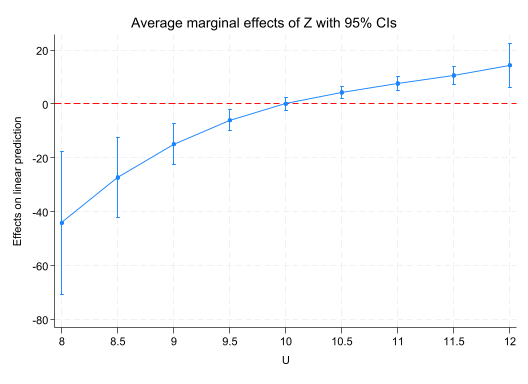

In [ ]:
*-计算 γ(U) = ∂Y/∂Z 在不同 U 水平下的边际效应
  margins, dydx(Z) at(U=(8(0.5)12))     // 0.5 -> 0.2
  marginsplot, yline(0, lc(red) lp(dash))

/*-调整 U 的步长以获得更平滑的边际效应曲线
  margins, dydx(Z) at(U=(8(0.1)12))     // 0.5 -> 0.2
  marginsplot, yline(0, lc(red) lp(dash)) xlabel(8(0.5)12)
*/

## 对比：使用 xtplfc 命令

Unable to drop fcoe_*

Computing the bootstrap standard errors...
.................................................50
.................................................100
.................................................150
.................................................200

Partially linear functional-coefficient panel data model.
Fixed-effect series semiparametric estimation.
Estimation results: linear part                 Number of obs        =    1365
                                                Within R-squared     =  0.1754
                                                Adj Within R-squared =  0.1693
                                                Root MSE             =  0.4291
------------------------------------------------------------------------------
       lngti | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
        lnrd |      0.089      0.053     1.68   0.092       -0.0

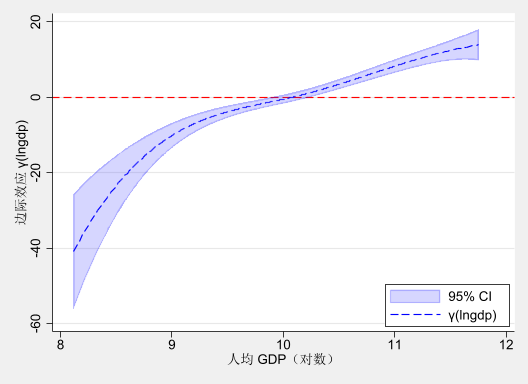

In [16]:
*-使用 xtplfc 命令：非参数估计

*----- 使用 xtplfc 估计
dropvars fcoe_*  
xtplfc lngti $xlist, zvars(er) uvar(lngdp) ///
       gen(fcoe_gti) power(3) nknots(2)  quantile  brep(200)

*----- 构造置信区间
gen fcoe_lb = fcoe_gti_1 - 1.96 * fcoe_gti_1_sd
gen fcoe_ub = fcoe_gti_1 + 1.96 * fcoe_gti_1_sd

*----- 绘图
twoway (rarea fcoe_lb fcoe_ub lngdp, color(blue%20) sort) ///
       (line  fcoe_gti_1 lngdp, lc(blue) lp(dash) sort), ///
       yline(0, lc(red) lp(dash)) ///
       xtitle("人均 GDP（对数）") ///
       ytitle("边际效应 γ(lngdp)") ///
       legend(order(1 "95% CI" 2 "γ(lngdp)") ///
              ring(0) pos(5) c(1)) ///
       scheme(s2mono)


## 结果解释示例

### 如何解读边际效应曲线？

- **横轴 (lngdp)** 是调节变量。本文中为「人均 GDP 的对数」，用以衡量城市的经济发展水平，取值范围在 8-12 之间。
- **纵轴 ($\partial{Y}/\partial{X} = \gamma(lngdp)$)**：表示 ER 对 GTI 的边际效应。正值表示 ER 促进 GTI；负值表示 ER 抑制 GTI；接近 0 则表示 ER 对 GTI 无显著影响。

**置信区间（灰色阴影）**：包含 0 表示边际效应不显著；不包含 0 表示边际效应显著。

**典型模式**：

1. **lngdp < 9**：边际效应为负 → 经济欠发达地区，ER 抑制 GTI
2. **9 < lngdp < 10**：边际效应接近 0 → 过渡阶段
3. **lngdp > 10**：边际效应为正且增强 → 经济发达地区，ER 促进 GTI

(631 real changes made)
(565 real changes made)
                    不显著区间：[9.89, 10.24]


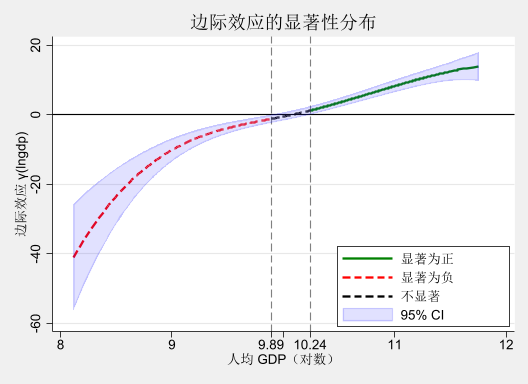

In [97]:
*----- 生成显著性指示变量
cap drop significant
gen significant = 0
replace significant = 1  if fcoe_lb > 0  // 显著为正
replace significant = -1 if fcoe_ub < 0 // 显著为负

cap label drop sig_lab
label define sig_lab -1 "显著为负" 0 "不显著" 1 "显著为正"
label values significant sig_lab

qui sum lngdp if significant==-1
global left_bound: dis %3.2f `r(max)'
qui sum lngdp if significant==1
global right_bound: dis %3.2f `r(min)'
dis _skip(20) "不显著区间：[$left_bound, $right_bound]"

*----- 按显著性分段绘图
twoway (line fcoe_gti_1 lngdp if significant==1, lc(green) lw(*2) sort) ///
       (line fcoe_gti_1 lngdp if significant==-1, lc(red) lw(*2) sort) ///
       (line fcoe_gti_1 lngdp if significant==0, lc(black) lw(*2) lp(dash) sort) ///
       (rarea fcoe_lb fcoe_ub lngdp, color(blue%15) sort), ///
       yline(0, lcolor(black)) ///
       xline($left_bound $right_bound, lc(gray) lp(dash)) ///
       xtitle("人均 GDP（对数）") ///
       ytitle("边际效应 γ(lngdp)") ///
       title("边际效应的显著性分布") ///
       xlabel(8 9 $left_bound 10 " " $right_bound 11 12) ///
       legend(order(1 "显著为正" 2 "显著为负" 3 "不显著" 4 "95% CI") ///
              ring(0) pos(5) c(1)) ///
       scheme(s2mono)

## 面板门槛模型估计

我们也可以使用 Hansen (1999) 提出的面板门槛模型来估计上述变系数面板数据模型。Stata 中可以使用 `xthreg` 命令来实现。

对应于 Du et al. (2021) 的问题背景，我们可以将单重面板门槛模型设定如下：

$$Y_{it} = \alpha_i 
        + Z_{it}^{\prime} {\gamma}_1 \cdot I\left(U_{it} \leq \lambda\right) 
        + Z_{it}^{\prime} {\gamma}_2 \cdot I\left(U_{it}>\lambda\right)
        + X_{it}\beta
        +\varepsilon_{it} \tag{1}
$$

双重门槛模型包含两个门槛值：$\lambda_1$ 和 $\lambda_2$，设定如下：

$$
Y_{it} = \alpha_i 
        + Z_{it}^{\prime} {\gamma}_1 \cdot I\left(U_{it} \leq \lambda_1\right) 
        + Z_{it}^{\prime} {\gamma}_2 \cdot I\left(\lambda_1 < U_{it} \ge \lambda_2\right)
        + Z_{it}^{\prime} {\gamma}_3 \cdot I\left(U_{it} < \lambda_2\right)
        + X_{it}\beta
        +\varepsilon_{it} \tag{1}
$$




In [12]:
use "https://github.com/lianxhcn/data/raw/refs/heads/main/stata/Du2021EE_ERdata.dta", clear

(Du et al. (2021, EE) https://doi.org/10.1016/j.eneco.2021.105247)


In [80]:
local xlist "lnrd lnpop lnhc lninv lnfdi"
xthreg lngti `xlist', rx(er) qx(lngdp) ///
       thnum(2) ///
       trim(0.10 0.10) ///
       bs(500 500) nobslog

Estimating  the  threshold  parameters:   1st ......  2nd ......  Done
Boostrapping for threshold effect test:   1st ......  2nd ......  Done

Threshold estimator (level = 95):
-----------------------------------------------------
     model |    Threshold         Lower         Upper
-----------+-----------------------------------------
      Th-1 |      10.3718       10.3260       10.3801
     Th-21 |      10.3718       10.3260       10.3801
     Th-22 |       9.3856        9.3739        9.3911
-----------------------------------------------------

Threshold effect test (bootstrap = 500 500):
-------------------------------------------------------------------------------
 Threshold |       RSS        MSE      Fstat    Prob   Crit10    Crit5    Crit1
-----------+-------------------------------------------------------------------
    Single |  386.0885     0.2652      62.21  0.0000  32.6949  38.3816  46.3104
    Double |  364.9414     0.2506      84.37  0.0000  21.5896  26.0920  38.6006

In [ ]:
eret list   // 查看返回值，需要执行时去掉前面的 * 即可

In [34]:
mat lambda = e(Thrss)  //存储门槛值的矩阵
mat list lambda


lambda[3,5]
       Threshold        RSS   Location      Lower      Upper
 Th-1  10.381698  386.06067        198  10.326203  10.385701
Th-21  10.381698  363.50086        191  10.333359  10.385701
Th-22  9.3875656  363.50086         47  9.3775396  9.3958902


In [41]:
*-记录门槛值 λ1 和 λ2
local lambda_1 = lambda[3,1]   // Th-22
local lambda_2 = lambda[2,1]   // Th-21
global lambda_1: dis %3.2f `lambda_1'  // 保留两位小数存储
global lambda_2: dis %3.2f `lambda_2'  // 保留两位小数存储

dis _skip(20) "门槛值：λ1 = ${lambda_1} , λ2 = ${lambda_2}"

                    门槛值：λ1 = 9.39 , λ2 = 10.38


In [53]:
*-记录系数估计值 γ1, γ2, γ3

global gamma_1: dis %3.2f _b[0._cat#c.er]
global gamma_2: dis %3.2f _b[1._cat#c.er]
global gamma_3: dis %3.2f _b[2._cat#c.er]

dis _skip(20) "系数估计值：γ1 = ${gamma_1} , γ2 = ${gamma_2} , γ3 = ${gamma_3}"

                    系数估计值：γ1 = -6.13 , γ2 = 1.60 , γ3 = 5.90


为了大家更好地理解变系数面板数据模型与面板门槛模型之间的联系，下面给出两者的对比图示。

我们先绘制面板门槛模型的估计结果，步骤如下：

1. 提取面板门槛模型的估计结果，包括边际效应的点估计和置信区间。边际效应  ($\hat{\gamma}_1, \hat{\gamma}_2, \hat{\gamma}_3$) 在三个区间内的估计值均为常数；置信区间也为常数，计算公式为 $\hat{\gamma}_j \pm 1.96 \times SE(\hat{\gamma}_j)$，其中 $j=1,2,3$。
2. 绘制边际效应随调节变量变化的图形。横轴为调节变量 $U$，纵轴为边际效应 $\gamma(U)$。在每个区间内绘制水平线表示边际效应的点估计，并用阴影区域表示置信区间。此外，在图中标注门槛值 $\lambda_1$ 和 $\lambda_2$ 以显示不同区间的分界点。

Unable to drop gamma*_lb gamma*_ub
(1,235 missing values generated)
(754 missing values generated)
(951 missing values generated)
(1,235 missing values generated)
(1,235 missing values generated)
(754 missing values generated)
(754 missing values generated)
(951 missing values generated)
(951 missing values generated)


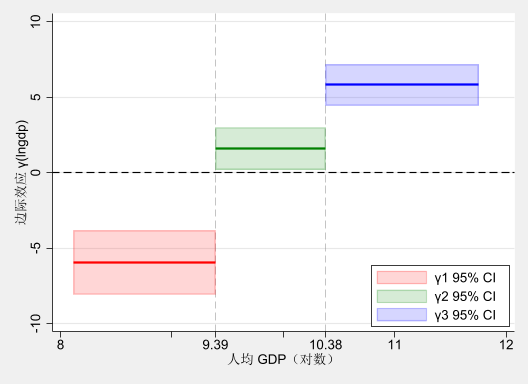

In [96]:
*-三个区间的系数估计值
dropvars gamma* gamma*_lb gamma*_ub

gen gamma1 = _b[0._cat#c.er] if inrange(lngdp, ., $lambda_1)
gen gamma2 = _b[1._cat#c.er] if inrange(lngdp, $lambda_1, $lambda_2)
gen gamma3 = _b[2._cat#c.er] if inrange(lngdp, $lambda_2, .)

*-计算置信区间 = 估计值 ± 1.96*标准误
gen gamma1_lb = gamma1 - 1.96 * _se[0._cat#c.er]
gen gamma1_ub = gamma1 + 1.96 * _se[0._cat#c.er]
gen gamma2_lb = gamma2 - 1.96 * _se[1._cat#c.er]
gen gamma2_ub = gamma2 + 1.96 * _se[1._cat#c.er]
gen gamma3_lb = gamma3 - 1.96 * _se[2._cat#c.er]
gen gamma3_ub = gamma3 + 1.96 * _se[2._cat#c.er]

*----- 绘图
twoway (rarea gamma1_lb gamma1_ub lngdp, color(red%20) sort) ///
       (rarea gamma2_lb gamma2_ub lngdp, color(green%20) sort) ///
       (rarea gamma3_lb gamma3_ub lngdp, color(blue%20) sort) ///
       (line  gamma1 lngdp, lc(red) lp(solid) lw(*2) sort) ///
       (line  gamma2 lngdp, lc(green) lp(solid) lw(*2) sort) ///
       (line  gamma3 lngdp, lc(blue) lp(solid) lw(*2) sort) ///
       , ///
       yline(0, lc(black) lp(dash)) ///
       xtitle("人均 GDP（对数）") ///
       ytitle("边际效应 γ(lngdp)") ///
       xline(${lambda_1} ${lambda_2}, lc(gray) lp(dash) lw(*0.4)) ///
       xlabel(8 9 " " ${lambda_1} 10 " " ${lambda_2} 11 12) ///
       legend(order(1 "γ1 95% CI" 2 "γ2 95% CI" 3 "γ3 95% CI") ///
              ring(0) pos(5) c(1)) ///
       scheme(s2mono)

下图将变系数面板数据模型与面板门槛模型的估计结果进行了对比。从图中可以看出：

- 两种方法得到基本结论是一致的：$Z$ 对 $Y$ 的边际影响具有异质性 —— 随着调节变量 $U$ 的变化而变化。具体而言，当 $U$ 取值较低时，边际效应为负；当 $U$ 取值较高时，边际效应为正。
- 两个模型在描述调节效应的变化特征时存在一些明显的差异。
  - 面板门槛模型假设在同一个区间内边际效应为常数，而发生区间转换时，边际效应会出现跳跃。最终，边际效应曲线呈现阶梯状变化。
  - 变系数面板数据模型则假设边际效应是调节变量的连续函数，因此边际效应曲线是平滑变化的，没有跳跃。从经济含义和统计性质来看，这种假设更为合理。
- 从转换的临界值角度来看，门槛模型会直接估计出门槛值 $\lambda_1$ 和 $\lambda_2$，而变系数模型则没有明确的门槛值，但可以通过分析边际效应曲线的置信区间来确定临界值范围 (边际效应不显著的区间对应的调节变量的取值区间内的最小值和最大值)。
  - 就本例 (Du et al., 2021) 而言，门槛模型估计出的「不显著」区间更宽一些。 


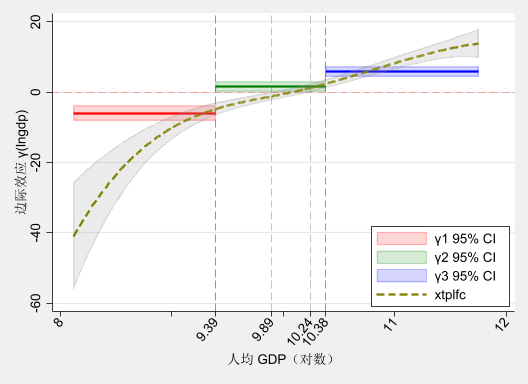

In [101]:
*----- 绘图
*local if1 "if inrange(fcoe_lb, -20, 20)"
*local if2 "if inrange(fcoe_gti_1, -20, 20)"
twoway (rarea gamma1_lb gamma1_ub lngdp, color(red%20) sort) ///
       (rarea gamma2_lb gamma2_ub lngdp, color(green%20) sort) ///
       (rarea gamma3_lb gamma3_ub lngdp, color(blue%20) sort) ///
       (line  gamma1 lngdp, lc(red) lp(solid) lw(*2) sort) ///
       (line  gamma2 lngdp, lc(green) lp(solid) lw(*2) sort) ///
       (line  gamma3 lngdp, lc(blue) lp(solid) lw(*2) sort) ///
       (rarea fcoe_lb fcoe_ub lngdp `if1', color(gray%20) sort) ///
       (line  fcoe_gti_1 lngdp `if2', lc(yellow*2) lp(dash) lw(*2) sort) ///
       , ///
       yline(0, lc(red*0.5) lp(dash) lw(*0.6)) ///
       xline($left_bound $right_bound, lc(gray) lp(dash) lw(*0.4)) ///
       xline(${lambda_1} ${lambda_2}, lc(blue) lp(dash) lw(*0.4)) ///
       xlabel(8 9 " " ${lambda_1} ${left_bound} 10 " " ///
              ${right_bound} ${lambda_2} 11 12, angle(50)) ///
       xtitle("人均 GDP（对数）") ///
       ytitle("边际效应 γ(lngdp)") ///
       legend(order(1 "γ1 95% CI" 2 "γ2 95% CI" 3 "γ3 95% CI" 8 "xtplfc") ///
              ring(0) pos(5) c(1)) ///
       scheme(s2mono)

## 小结

在实证分析中，建议优先采用变系数面板数据模型来刻画调节效应的异质性特征。当然，你也可以在稳健性检验中使用面板门槛模型来进行对比分析。

相比之下，门槛模型有如下几个劣势：

- **模型设定方面**：由于我们预先并不知道会有几个门槛值，因此需要使用 Hansen (1999) 建议的 Bootstrap 方法来确定门槛值的个数，这增加了计算复杂性。当样本较小时 (如省级面板数据，$N=30, T=20$)，搜索出的门槛值往往不准确；当样本较大时 (如上市公司面板数据，$N=3000, T=15$)，计算时间会显著增加。事实上，更本质的影响来自于调节变量的分布特征，当调节变量中的非重复值 (unique values) 较少，或分布极度不均衡 (如，70% 以上的样本都集中在一个比较窄的区间内) 时，门槛模型的估计结果往往不稳定。
- **估计结果方面**：在搜索门槛值过程中，为了避免某个区间内的样本数过少，通常会设置每个区间的最小样本比例 (如 10%，通过 `xthreg` 中的选项 `trim(0.1)` 来实现)。该参数的选择存在很强的主观性，需要增加额外的稳健性测试。
- **假设检验方面**：在检验门槛效应是否显著时 (用以判断门槛值的个数)，需要使用 Bootstrap 方法来计算经验 p 值 (通过 `xthreg` 中的选项 `bsrep()` 来实现)，通常需要设定较大的抽样次数 (如 `bsrep(1000)`) 才能保证相对稳定的结果。

## 参考文献

- Du, K., Cheng, Y., & Yao, X. (2021). Environmental regulation, green technology innovation, and industrial structure upgrading: The road to the green transformation of Chinese cities. **Energy Economics**, 98, 105247. [Link](https://doi.org/10.1016/j.eneco.2021.105247) (rep), [PDF](http://sci-hub.ren/10.1016/j.eneco.2021.105247), [-Replication-](https://ars.els-cdn.com/content/image/1-s2.0-S0140988321001523-mmc1.zip), [Google](<https://scholar.google.com/scholar?q=Environmental regulation, green technology innovation, and industrial structure upgrading: The road to the green transformation of Chinese cities>). 
- Du, C., et al. (2024). Does manufacturing agglomeration promote green productivity growth in China? **Energy Economics**. [Link](https://doi.org/10.1016/j.eneco.2024.107352), [PDF](https://file-lianxh.oss-cn-shenzhen.aliyuncs.com/Refs/refs_common/Du_2024_EE-Does_manufacturing_agglomeration.pdf), [Replication](https://ars.els-cdn.com/content/image/1-s2.0-S0140988324000604-mmc1.zip)